# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [3]:
gw_df = pd.read_csv("groundwater_prediction_dataset.csv")
gw_df["Data Acquisition Time"] = pd.to_datetime(gw_df["Data Acquisition Time"], errors="coerce")

print("Shape:", gw_df.shape)
print("\nColumns:", gw_df.columns.tolist())

Shape: (104306, 5)

Columns: ['Data Acquisition Time', 'District LGD Code', 'District', 'rainfall', 'groundwater_level']


In [4]:
print(gw_df.info())

print("\n===== DESCRIPTIVE STATS =====")
print(gw_df.describe())

print("\n===== UNIQUE DISTRICTS =====")
print("District count:", gw_df["District"].nunique())
print(sorted(gw_df["District"].unique()))

<class 'pandas.DataFrame'>
RangeIndex: 104306 entries, 0 to 104305
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Data Acquisition Time  104306 non-null  datetime64[us]
 1   District LGD Code      104306 non-null  int64         
 2   District               104306 non-null  str           
 3   rainfall               104306 non-null  float64       
 4   groundwater_level      104306 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 4.0 MB
None

===== DESCRIPTIVE STATS =====
            Data Acquisition Time  District LGD Code       rainfall  \
count                      104306      104306.000000  104306.000000   
mean   2024-04-26 16:25:25.522980         594.442151       9.304817   
min           2021-09-16 17:25:00         568.000000       0.500000   
25%           2023-07-19 02:00:00         576.000000       0.500000   
50%          

In [5]:
gw_df["year"] = gw_df["Data Acquisition Time"].dt.year
gw_df["month"] = gw_df["Data Acquisition Time"].dt.month
gw_df["day"] = gw_df["Data Acquisition Time"].dt.day
gw_df["hour"] = gw_df["Data Acquisition Time"].dt.hour
gw_df["day_of_week"] = gw_df["Data Acquisition Time"].dt.dayofweek

In [7]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"
gw_df["season"] = gw_df["month"].apply(get_season)

In [8]:
print("\n===== MISSING VALUES =====")
print(gw_df.isnull().sum())

print("\n===== DUPLICATES =====")
print("Duplicate rows:", gw_df.duplicated().sum())


===== MISSING VALUES =====
Data Acquisition Time    0
District LGD Code        0
District                 0
rainfall                 0
groundwater_level        0
year                     0
month                    0
day                      0
hour                     0
day_of_week              0
season                   0
dtype: int64

===== DUPLICATES =====
Duplicate rows: 0


# Plots

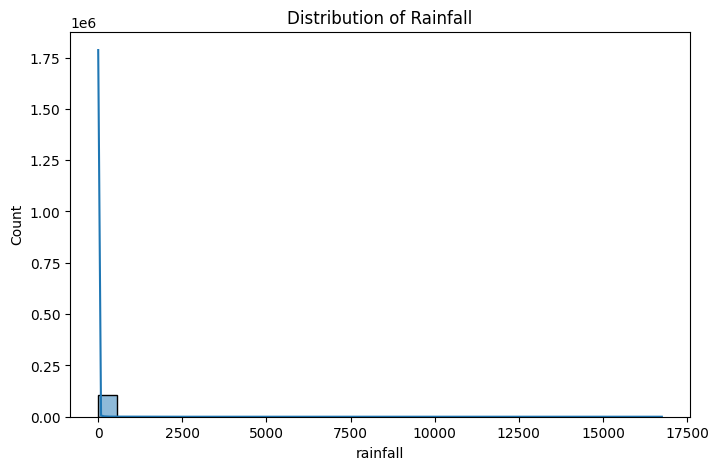

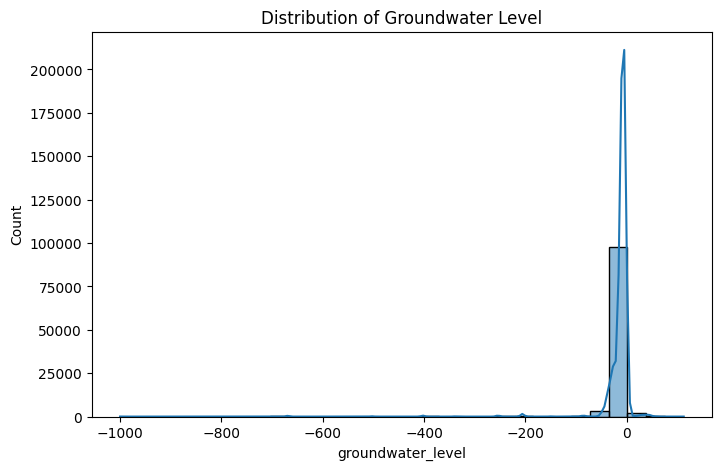

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(gw_df["rainfall"], kde=True, bins=30)
plt.title("Distribution of Rainfall")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(gw_df["groundwater_level"], kde=True, bins=30)
plt.title("Distribution of Groundwater Level")
plt.show()

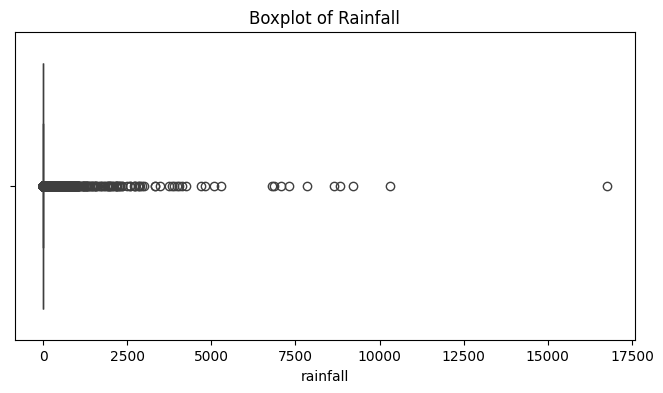

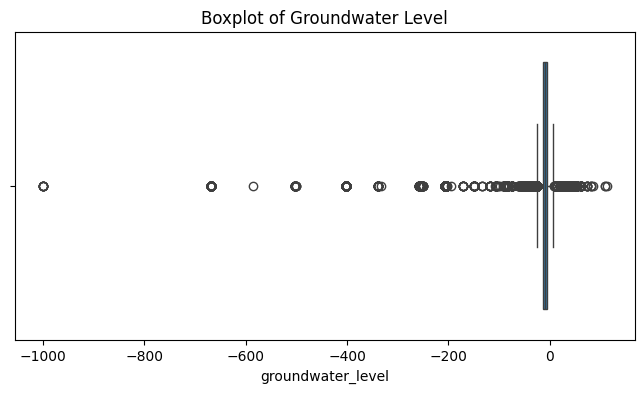

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=gw_df["rainfall"])
plt.title("Boxplot of Rainfall")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=gw_df["groundwater_level"])
plt.title("Boxplot of Groundwater Level")
plt.show()

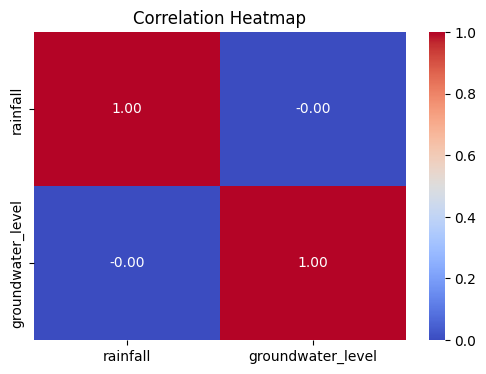


===== CORRELATION =====
                   rainfall  groundwater_level
rainfall           1.000000          -0.000169
groundwater_level -0.000169           1.000000


In [11]:
corr = gw_df[["rainfall", "groundwater_level"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\n===== CORRELATION =====")
print(corr)

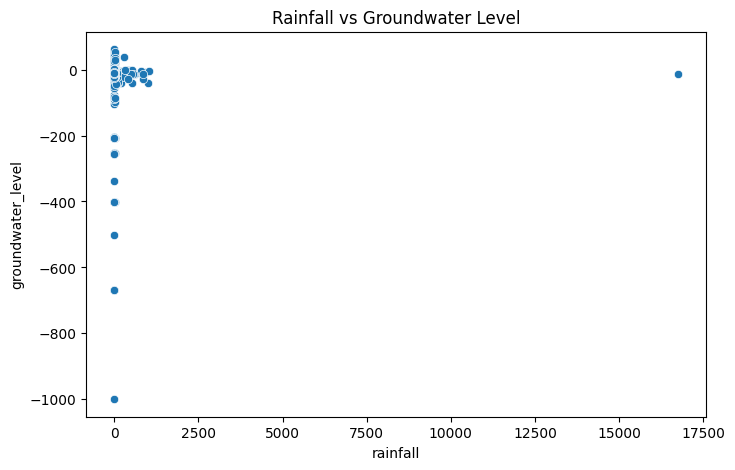

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=gw_df.sample(min(5000, len(gw_df))), x="rainfall", y="groundwater_level")
plt.title("Rainfall vs Groundwater Level")
plt.show()


===== MONTHLY AVERAGES =====
        rainfall  groundwater_level
month                              
1      10.081819         -13.580997
2       4.655981         -13.824895
3      10.716043          -8.209077
4       7.140094         -10.404488
5       6.339718         -11.092292
6       5.913202         -11.298248
7      22.121130         -13.564477
8       6.574482         -12.534286
9       6.751593         -14.217774
10     10.459303         -19.323016
11     11.003447         -13.995648
12      6.346372         -11.945586


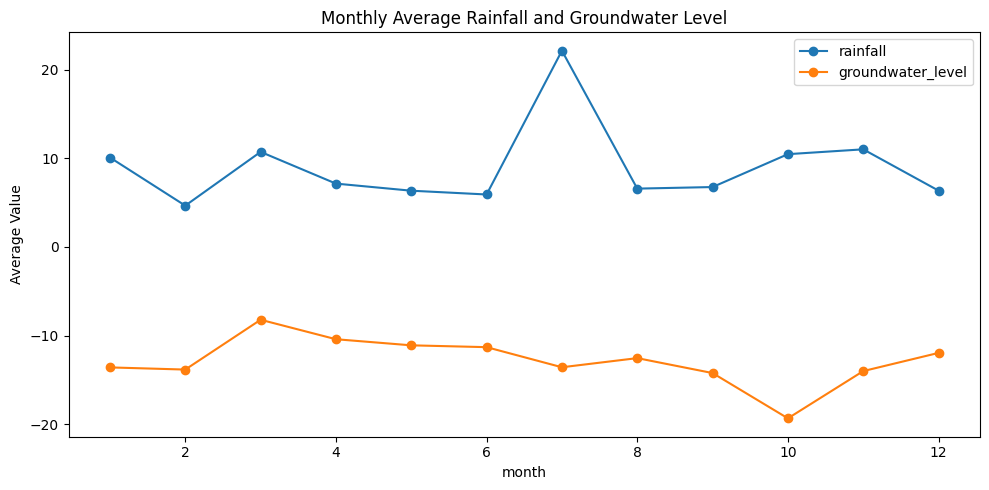

In [13]:
monthly_avg = gw_df.groupby("month")[["rainfall", "groundwater_level"]].mean()
print("\n===== MONTHLY AVERAGES =====")
print(monthly_avg)

monthly_avg.plot(figsize=(10,5), marker='o')
plt.title("Monthly Average Rainfall and Groundwater Level")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


===== SEASONAL AVERAGES =====
               rainfall  groundwater_level
season                                    
Monsoon       10.115711         -12.862732
Post-Monsoon  10.773384         -16.248051
Summer         7.430332         -10.337106
Winter         7.177861         -12.512322


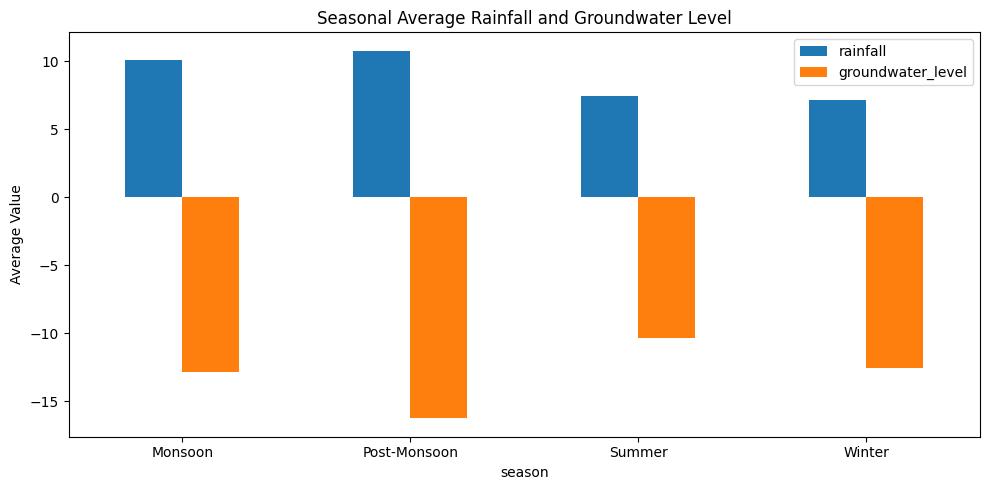

In [14]:
seasonal_avg = gw_df.groupby("season")[["rainfall", "groundwater_level"]].mean()
print("\n===== SEASONAL AVERAGES =====")
print(seasonal_avg)

seasonal_avg.plot(kind="bar", figsize=(10,5))
plt.title("Seasonal Average Rainfall and Groundwater Level")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



===== DISTRICT-WISE AVERAGES =====
                  rainfall  groundwater_level
District                                     
Salem             9.038422          12.364340
Thoothukudi       3.233816           0.859230
Chengalpattu      5.863795          -1.220576
Virudhunagar     10.424429          -3.383769
Kancheepuram      3.780543          -3.537325
Ranipet           2.450374          -3.860587
Tenkasi           4.237460          -3.872432
Tiruvannamalai    4.229223          -3.946617
Chennai           3.450140          -4.031751
Kallakurichi     24.332449          -4.157907
Tirunelveli       3.961753          -4.596596
Madurai           3.895487          -5.161764
Tiruchirappalli   3.844443          -5.236734
Nagapattinam      8.219208          -7.146400
Sivaganga         4.051221          -7.190177
Tiruvallur        3.147828          -7.473542
Karur            11.646596          -8.298264
Kanyakumari       4.094724          -9.499414
Theni             2.184009          -9.57147

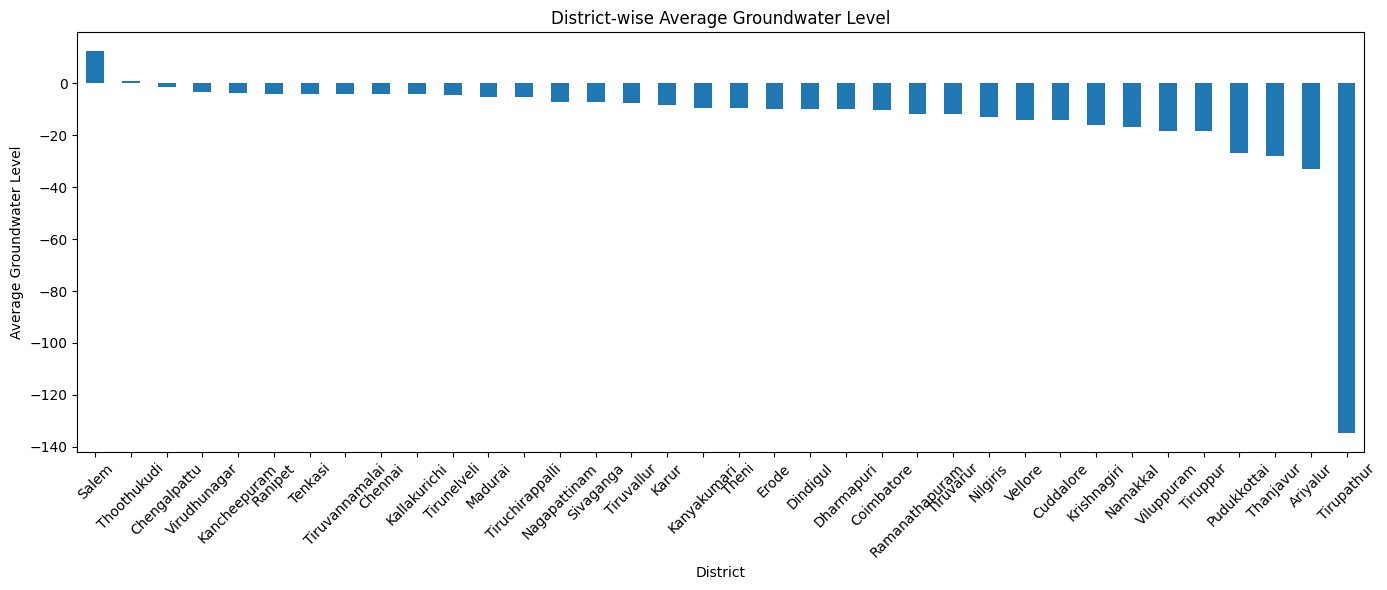

In [15]:
district_avg = gw_df.groupby("District")[["rainfall", "groundwater_level"]].mean().sort_values("groundwater_level", ascending=False)

print("\n===== DISTRICT-WISE AVERAGES =====")
print(district_avg)

district_avg["groundwater_level"].plot(kind="bar", figsize=(14,6))
plt.title("District-wise Average Groundwater Level")
plt.ylabel("Average Groundwater Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



===== YEARLY AVERAGES =====
       rainfall  groundwater_level
year                              
2021   3.226754         -12.475558
2022  17.197410         -12.257421
2023  13.093363         -18.471175
2024   6.288186         -13.396066
2025   4.896767          -9.180156
2026   6.294949         -10.515674


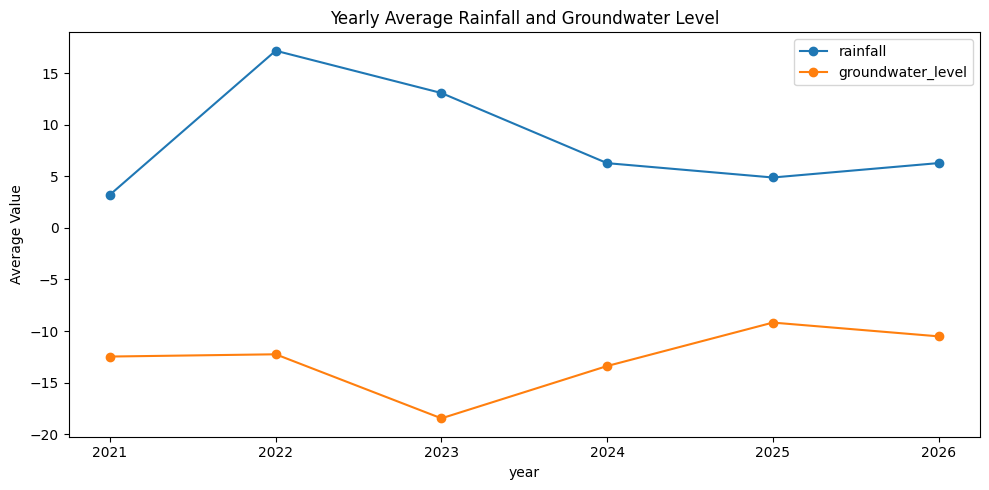

In [16]:
yearly_avg = gw_df.groupby("year")[["rainfall", "groundwater_level"]].mean()
print("\n===== YEARLY AVERAGES =====")
print(yearly_avg)

yearly_avg.plot(figsize=(10,5), marker='o')
plt.title("Yearly Average Rainfall and Groundwater Level")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Load data

In [3]:
flood_df = pd.read_csv("flood_risk_dataset.csv")
flood_df["Data Acquisition Time"] = pd.to_datetime(flood_df["Data Acquisition Time"], errors="coerce")

print("Shape:", flood_df.shape)
print("\nColumns:", flood_df.columns.tolist())


Shape: (6119, 6)

Columns: ['Data Acquisition Time', 'District LGD Code', 'District', 'rainfall', 'river_water_level', 'groundwater_level']


In [4]:
print("\n===== INFO =====")
print(flood_df.info())

print("\n===== DESCRIPTIVE STATS =====")
print(flood_df.describe())

print("\n===== DISTRICTS =====")
print("District count:", flood_df["District"].nunique())
print(sorted(flood_df["District"].unique()))


===== INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 6119 entries, 0 to 6118
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Data Acquisition Time  6119 non-null   datetime64[us]
 1   District LGD Code      6119 non-null   int64         
 2   District               6119 non-null   str           
 3   rainfall               6119 non-null   float64       
 4   river_water_level      6119 non-null   float64       
 5   groundwater_level      6119 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 287.0 KB
None

===== DESCRIPTIVE STATS =====
            Data Acquisition Time  District LGD Code     rainfall  \
count                        6119        6119.000000  6119.000000   
mean   2024-07-19 13:03:09.001471         577.702566    18.586254   
min           2022-03-04 13:00:00         568.000000     0.500000   
25%           2023-11-01

In [5]:
flood_df["year"] = flood_df["Data Acquisition Time"].dt.year
flood_df["month"] = flood_df["Data Acquisition Time"].dt.month
flood_df["day"] = flood_df["Data Acquisition Time"].dt.day
flood_df["hour"] = flood_df["Data Acquisition Time"].dt.hour
flood_df["day_of_week"] = flood_df["Data Acquisition Time"].dt.dayofweek

In [6]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

flood_df["season"] = flood_df["month"].apply(get_season)

In [7]:
print("\n===== MISSING VALUES =====")
print(flood_df.isnull().sum())

print("\n===== DUPLICATES =====")
print("Duplicate rows:", flood_df.duplicated().sum())


===== MISSING VALUES =====
Data Acquisition Time    0
District LGD Code        0
District                 0
rainfall                 0
river_water_level        0
groundwater_level        0
year                     0
month                    0
day                      0
hour                     0
day_of_week              0
season                   0
dtype: int64

===== DUPLICATES =====
Duplicate rows: 0


# Plots

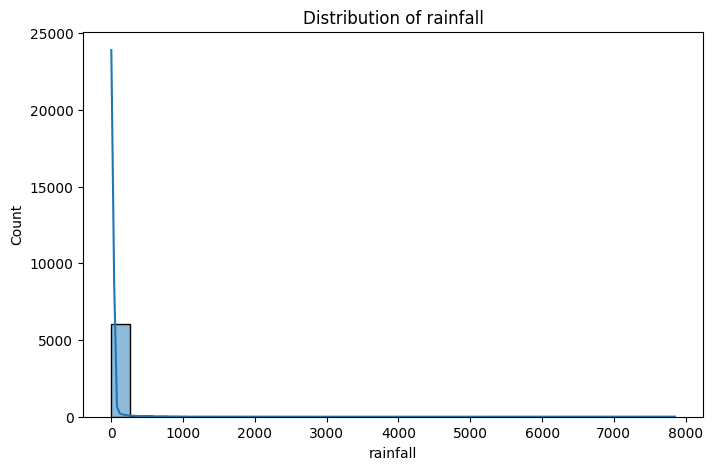

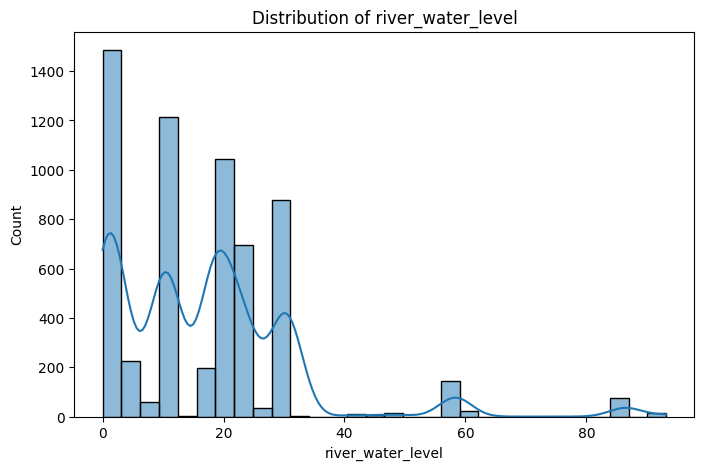

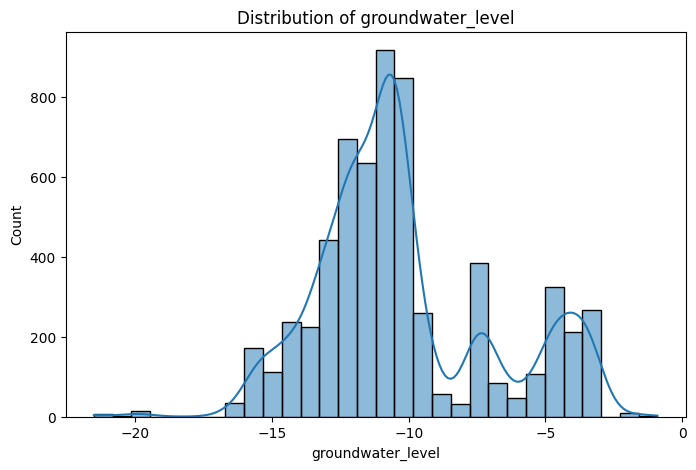

In [8]:
for col in ["rainfall", "river_water_level", "groundwater_level"]:
    plt.figure(figsize=(8,5))
    sns.histplot(flood_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

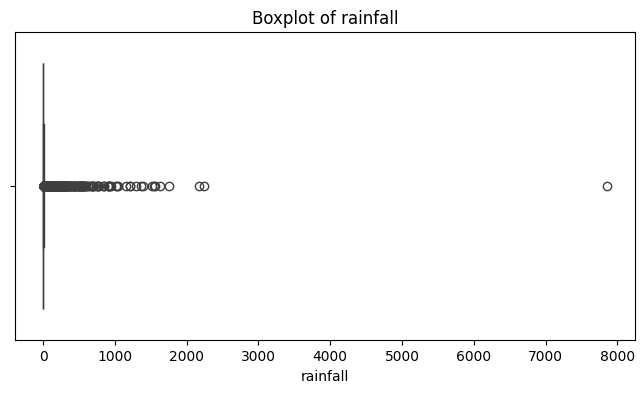

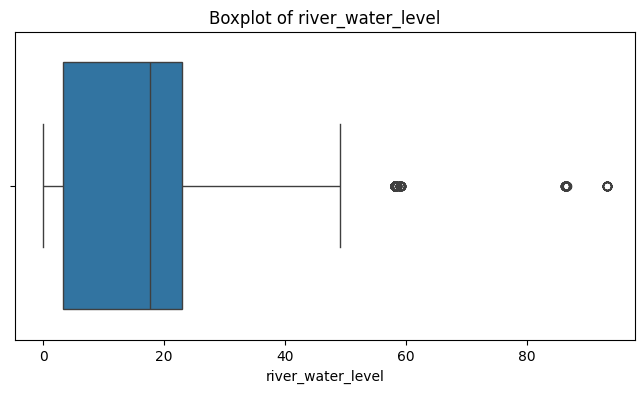

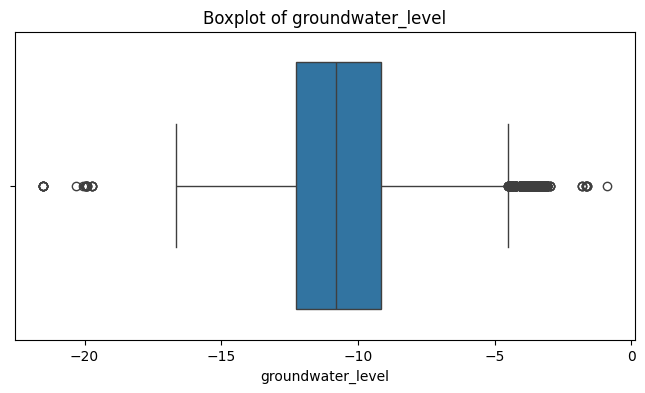

In [9]:
for col in ["rainfall", "river_water_level", "groundwater_level"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=flood_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

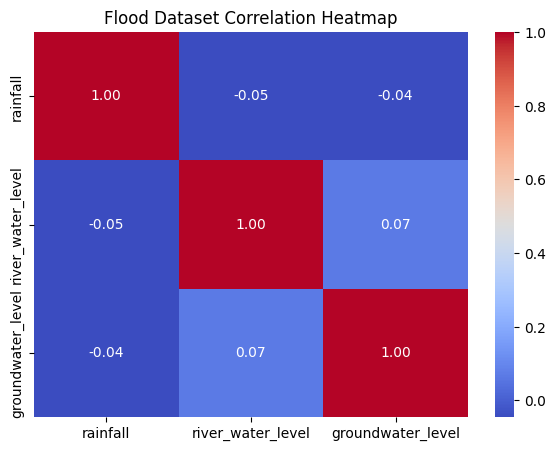


===== CORRELATION =====
                   rainfall  river_water_level  groundwater_level
rainfall           1.000000          -0.045226          -0.043391
river_water_level -0.045226           1.000000           0.065855
groundwater_level -0.043391           0.065855           1.000000


In [10]:
corr = flood_df[["rainfall", "river_water_level", "groundwater_level"]].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Flood Dataset Correlation Heatmap")
plt.show()

print("\n===== CORRELATION =====")
print(corr)

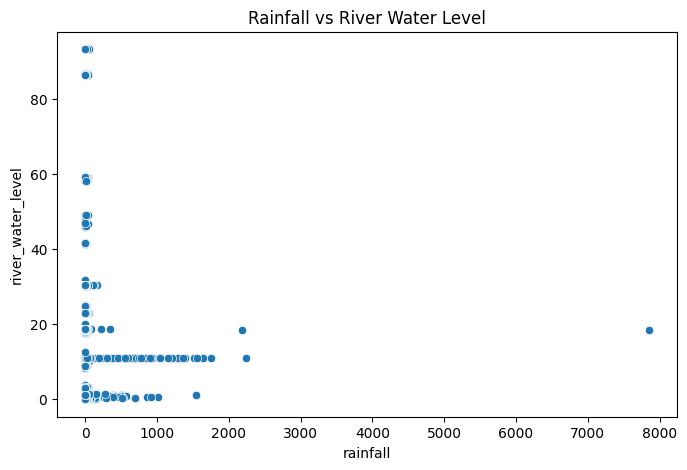

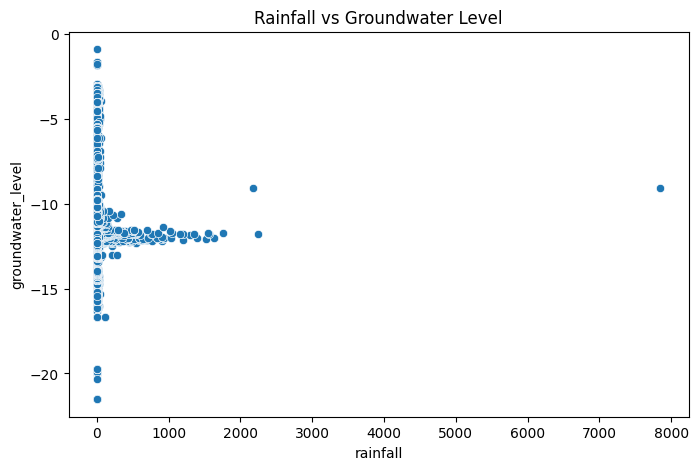

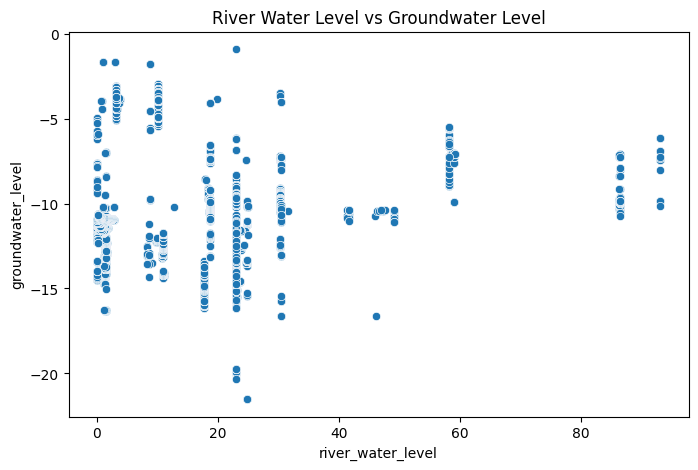

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=flood_df, x="rainfall", y="river_water_level")
plt.title("Rainfall vs River Water Level")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=flood_df, x="rainfall", y="groundwater_level")
plt.title("Rainfall vs Groundwater Level")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=flood_df, x="river_water_level", y="groundwater_level")
plt.title("River Water Level vs Groundwater Level")
plt.show()



===== MONTHLY AVERAGES =====
        rainfall  river_water_level  groundwater_level
month                                                 
1       2.103268          17.761321          -8.890794
2       2.088028          19.685268         -11.094360
3      56.979920          19.252633         -11.206492
4       4.592850          29.159000         -10.425668
5       4.136929          27.077788          -9.192244
6       4.150665          23.713388          -9.289523
7       3.172769          19.649939         -10.453370
8       5.235052          23.883354         -11.202514
9      25.709476          16.428064         -10.953285
10     40.024144          18.531705         -10.309477
11     23.009892          10.290720         -10.674046
12      2.694392          11.790942          -9.251181


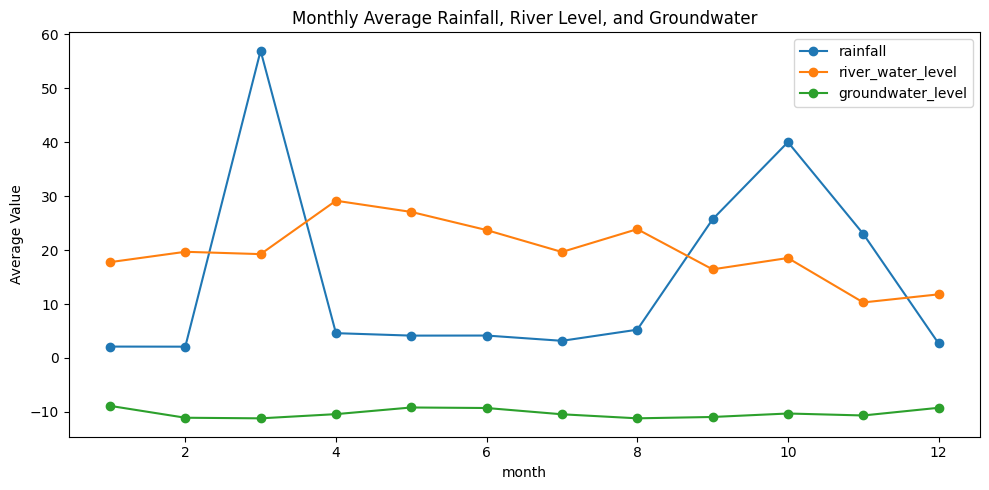

In [12]:
monthly_avg = flood_df.groupby("month")[["rainfall", "river_water_level", "groundwater_level"]].mean()
print("\n===== MONTHLY AVERAGES =====")
print(monthly_avg)

monthly_avg.plot(figsize=(10,5), marker='o')
plt.title("Monthly Average Rainfall, River Level, and Groundwater")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


===== SEASONAL AVERAGES =====
               rainfall  river_water_level  groundwater_level
season                                                       
Monsoon       11.042039          20.980210         -10.759948
Post-Monsoon  30.075343          13.712926         -10.522653
Summer        19.726246          25.311475         -10.093324
Winter         2.523639          13.608442          -9.263201


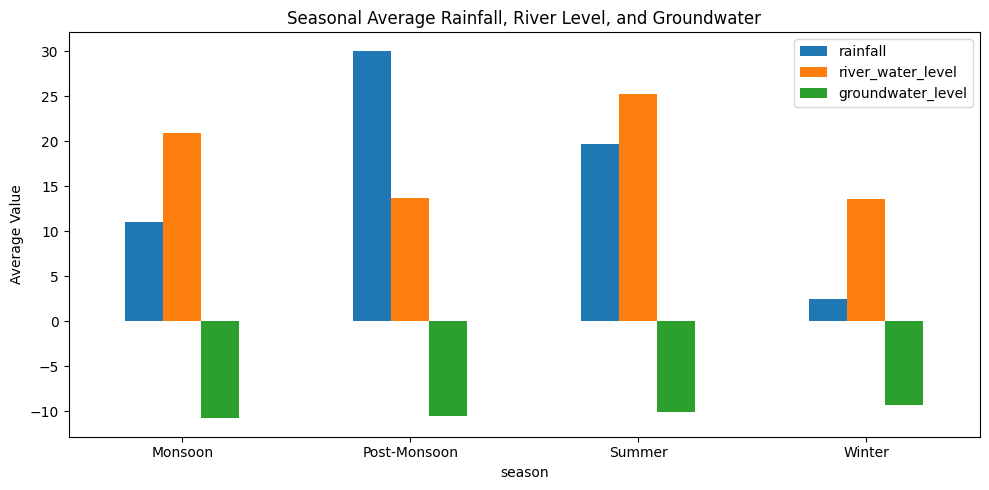

In [13]:
seasonal_avg = flood_df.groupby("season")[["rainfall", "river_water_level", "groundwater_level"]].mean()
print("\n===== SEASONAL AVERAGES =====")
print(seasonal_avg)

seasonal_avg.plot(kind="bar", figsize=(10,5))
plt.title("Seasonal Average Rainfall, River Level, and Groundwater")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


===== DISTRICT-WISE AVERAGES =====
                 rainfall  river_water_level  groundwater_level
District                                                       
Chennai          3.424197           8.265074          -4.125992
Cuddalore        2.301201          13.352645         -13.206439
Ramanathapuram  31.936021          16.664188         -10.676696
Sivaganga        3.668407          47.006486          -7.840461


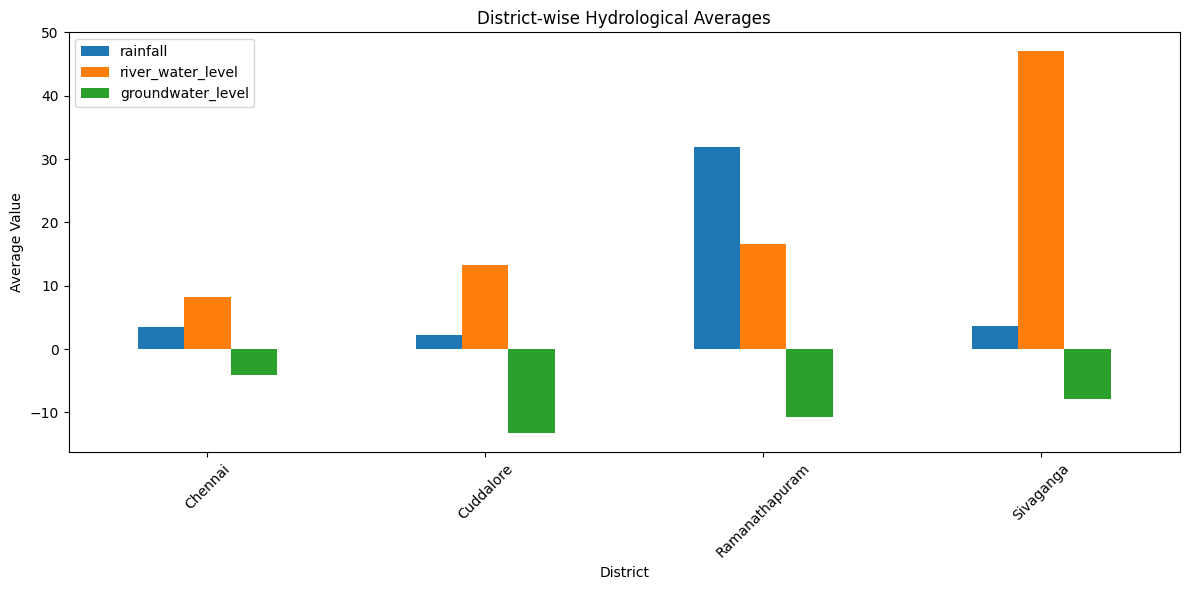

In [14]:
district_avg = flood_df.groupby("District")[["rainfall", "river_water_level", "groundwater_level"]].mean()

print("\n===== DISTRICT-WISE AVERAGES =====")
print(district_avg)

district_avg.plot(kind="bar", figsize=(12,6))
plt.title("District-wise Hydrological Averages")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


===== YEARLY AVERAGES =====
       rainfall  river_water_level  groundwater_level
year                                                 
2022   2.247032           3.983698         -13.240150
2023  66.843477           5.752840         -11.634222
2024   9.225239          18.200648          -8.024461
2025   3.850240          27.917941         -10.133156
2026   2.227414          16.595430          -9.785680


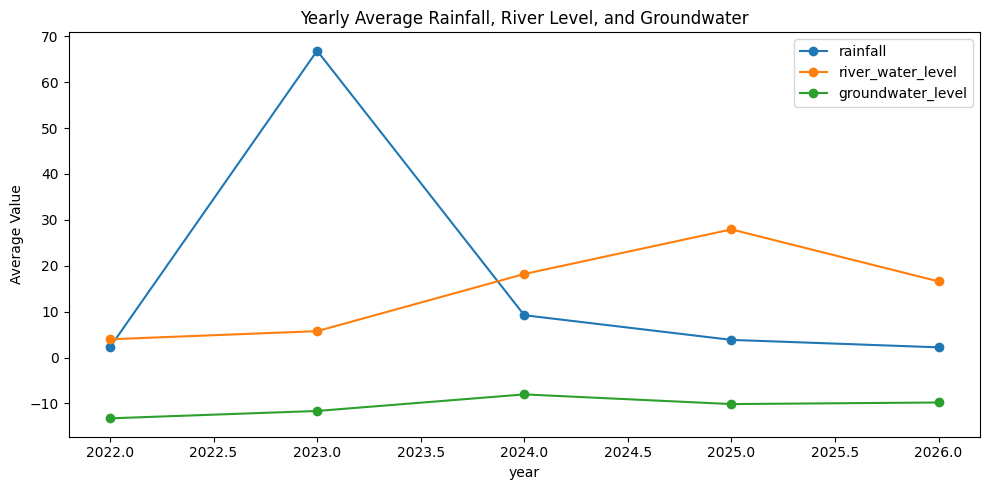

In [15]:
yearly_avg = flood_df.groupby("year")[["rainfall", "river_water_level", "groundwater_level"]].mean()
print("\n===== YEARLY AVERAGES =====")
print(yearly_avg)

yearly_avg.plot(figsize=(10,5), marker='o')
plt.title("Yearly Average Rainfall, River Level, and Groundwater")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()